<a href="https://colab.research.google.com/github/RaihanDaffa04/PCVK_Ganjil2026/blob/main/Week06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

D. PRAKTIKUM FILTER

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

In [4]:
def convolution2d(image, kernel, stride, padding):
    image_padded = np.pad(image, pad_width=padding, mode='constant', constant_values=0)

    img_height, img_width = image_padded.shape
    kernel_height, kernel_width = kernel.shape

    output_height = int((img_height - kernel_height) / stride) + 1
    output_width = int((img_width - kernel_width) / stride) + 1

    output = np.zeros((output_height, output_width))

    for y in range(output_height):
        for x in range(output_width):
            y_start = y * stride
            y_end = y_start + kernel_height
            x_start = x * stride
            x_end = x_start + kernel_width

            roi = image_padded[y_start:y_end, x_start:x_end]

            output[y, x] = np.sum(roi * kernel)
    cv2_imshow(output)

    return output

In [5]:
img = cv.imread('/content/drive/MyDrive//PCVK/Images/mandrill.tiff')
img_gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)

Hasil Sharpen:


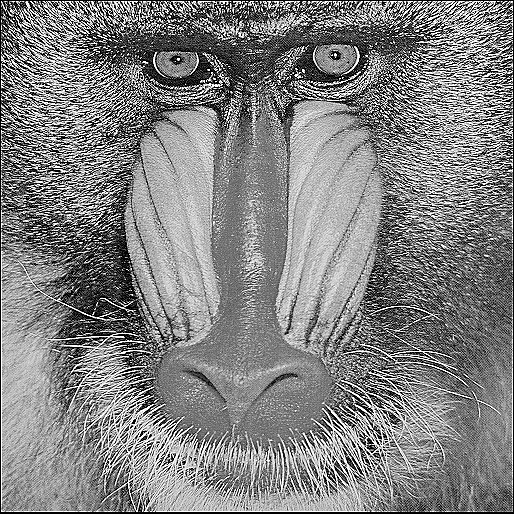

In [12]:
#image sharpen
kernel_sharpen = np.array([[0,-1,0],
                           [-1,5,-1],
                           [0,-1,0]])
print("Hasil Sharpen:")
convolution2d(img_gray,kernel_sharpen,1,2);

Hasil Emboss:


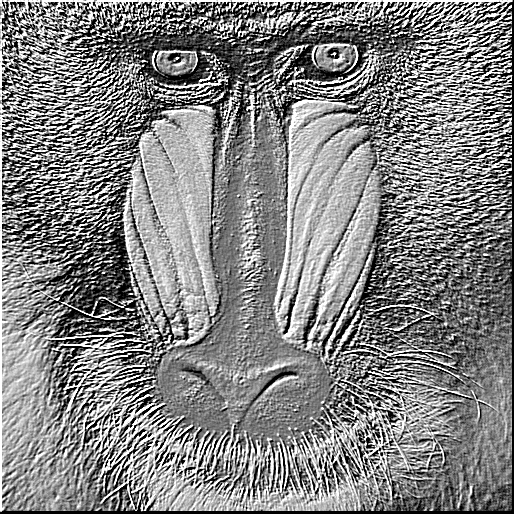

In [13]:
kernel_emboss = np.array([[-2, -1, 0],
                          [-1, 1, 1],
                          [0, 1, 2]])
print("Hasil Emboss:")
convolution2d(img_gray, kernel_emboss, 1, 2);

Hasil Left Sobel Edge Detection:


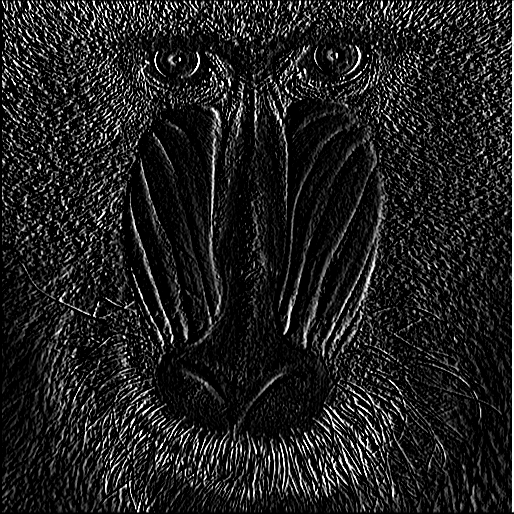

In [14]:
kernel_left_sobel = np.array([[1, 0, -1],
                              [2, 0, -2],
                              [1, 0, -1]])
print("Hasil Left Sobel Edge Detection:")
convolution2d(img_gray, kernel_left_sobel, 1, 2);

Hasil Canny Edge Detection:


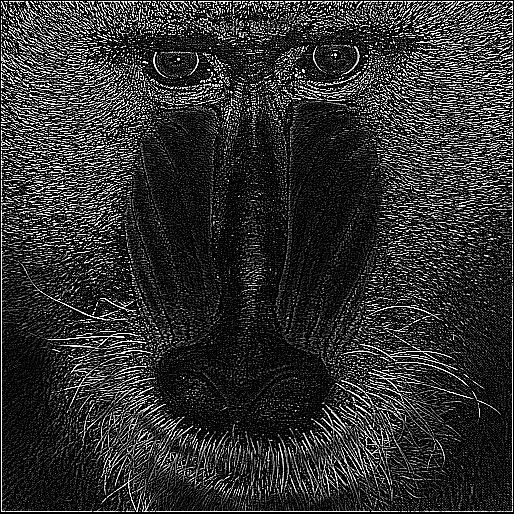

In [15]:
kernel_canny = np.array([[-1, -1, -1],
                         [-1, 8, -1],
                         [-1, -1, -1]])
print("Hasil Canny Edge Detection:")
convolution2d(img_gray, kernel_canny, 1, 2);

Hasil 21x21 Gaussian Blur:


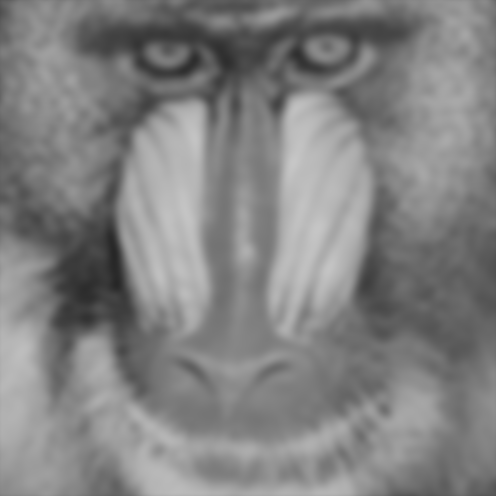

In [16]:
kernel_size = 21
sigma = math.sqrt(kernel_size)
gaussian_kernel = cv.getGaussianKernel(kernel_size, sigma)
gauss_kernel = gaussian_kernel @ gaussian_kernel.transpose()

print("Hasil 21x21 Gaussian Blur:")
convolution2d(img_gray, gauss_kernel, 1, 2);

E. FILTER LIBRARY DAN FILTER MODERN

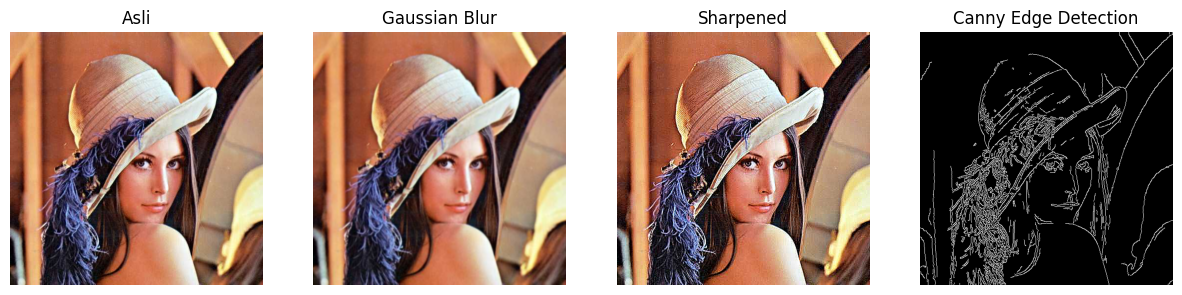

In [18]:
# Fungsi tampil berdampingan
def show_side_by_side(images, titles, figsize=(15,5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        if len(img.shape) == 2:  # grayscale
            plt.subplot(1, len(images), i+1)
            plt.imshow(img, cmap="gray")
        else:  # color
            plt.subplot(1, len(images), i+1)
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()

img = cv.imread("/content/drive/MyDrive/PCVK/Images/lena.jpg")
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

blur = cv.GaussianBlur(img, (7,7), 1)
edges = cv.Canny(cv.cvtColor(img, cv.COLOR_BGR2GRAY), 100, 200)
sharpen_kernel = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
sharpened = cv.filter2D(img, -1, sharpen_kernel)
show_side_by_side([img, blur, sharpened, edges],
                  ["Asli", "Gaussian Blur", "Sharpened", "Canny Edge Detection"])

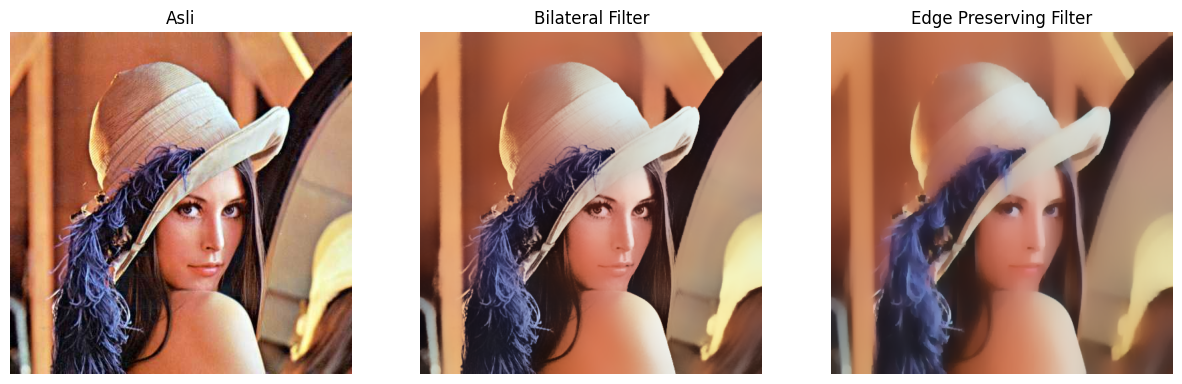

In [19]:
#Filter Modern dari OpenCV
# Bilateral Filter (edge-preserving)
bilateral = cv.bilateralFilter(img, 50, 100, 100)

# Edge Preserving Filter (alternatif Guided Filter)
edge_preserve = cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)

show_side_by_side([img, bilateral, edge_preserve],
                  ["Asli", "Bilateral Filter", "Edge Preserving Filter"])

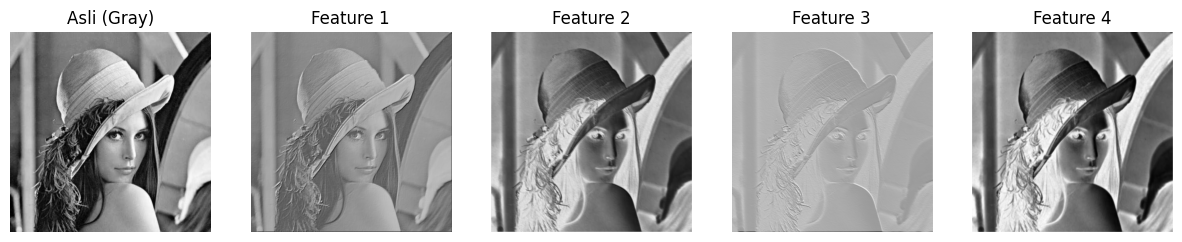

In [20]:
#Filter Feature Map yang digunakan pada CNN, Lakukan running code Bagian ini beberapa kali dan perhatikan hasilnya
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        return self.conv1(x)

model = SimpleCNN()

# Ubah gambar ke tensor
img_tensor = torch.tensor(img_gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

# Hasil CNN
with torch.no_grad():
    features = model(img_tensor)

# Visualisasi feature maps
feature_maps = [features[0,i].numpy() for i in range(features.shape[1])]
show_side_by_side([img_gray] + feature_maps, ["Asli (Gray)"] + [f"Feature {i+1}" for i in range(len(feature_maps))])

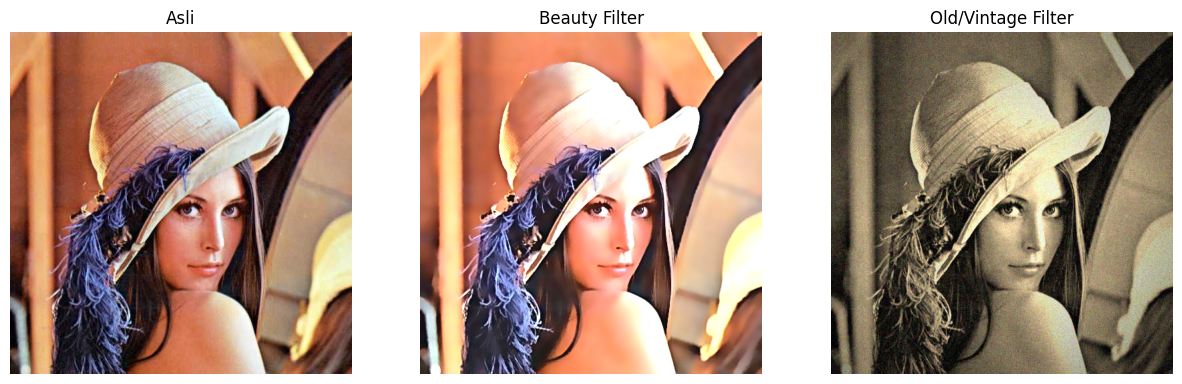

In [25]:
# =========================
# 1. Beauty Filter
# =========================
# Step 1: Smoothing kulit dengan bilateral filter
smooth = cv.bilateralFilter(img, d=15, sigmaColor=75, sigmaSpace=75)

# Step 2: Unsharp masking (pertajam mata/bibir)
gaussian = cv.GaussianBlur(smooth, (0,0), 3)
sharpened = cv.addWeighted(smooth, 1.5, gaussian, -0.5, 0)

# Step 3: Brightness & contrast
alpha = 1.2  # contrast
beta = 15    # brightness
beauty = cv.convertScaleAbs(sharpened, alpha=alpha, beta=beta)

# =========================
# 2. Old/Vintage Filter
# =========================
# Step 1: Sepia tone
sepia_kernel = np.array([[0.272, 0.534, 0.131],
                         [0.349, 0.686, 0.168],
                         [0.393, 0.769, 0.189]])
sepia = cv.transform(img, sepia_kernel)
sepia = np.clip(sepia, 0, 255).astype(np.uint8)

# Step 2: Vignette
rows, cols = img.shape[:2]
kernel_x = cv.getGaussianKernel(cols, cols*0.6)
kernel_y = cv.getGaussianKernel(rows, rows*0.6)
kernel = kernel_y * kernel_x.T
mask = kernel / kernel.max()
vignette = np.copy(sepia)
for i in range(3):
    vignette[:,:,i] = vignette[:,:,i] * mask

# Step 3: Noise/Grain
noise = np.random.normal(0, 15, vignette.shape).astype(np.int16)
old_img = np.clip(vignette.astype(np.int16) + noise, 0, 255).astype(np.uint8)

show_side_by_side([img, beauty, old_img],
                  ["Asli", "Beauty Filter", "Old/Vintage Filter"])

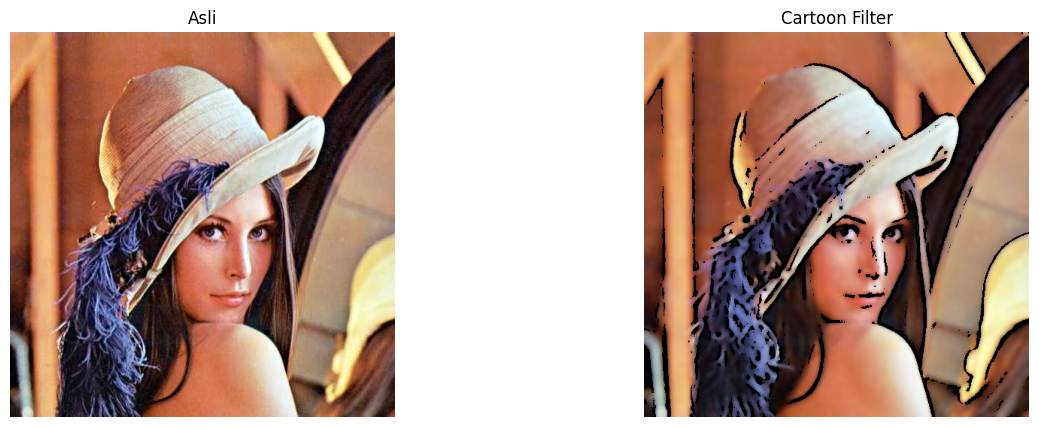

In [22]:
#Filter Anime / Cartoon
# Step 1: Edge detection (pakai median blur dulu agar gambar menjadi lebih halus)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_blur = cv.medianBlur(gray, 7)
edges = cv.adaptiveThreshold(gray_blur, 255,
                             cv.ADAPTIVE_THRESH_MEAN_C,
                             cv.THRESH_BINARY, 9, 9)

# Step 2: Bilateral filter untuk smoothing warna
color = cv.bilateralFilter(img, d=9, sigmaColor=300, sigmaSpace=300)

# Step 3: Gabungkan (cartoonize)
cartoon = cv.bitwise_and(color, color, mask=edges)

# Tampilkan
show_side_by_side([img, cartoon], ["Asli", "Cartoon Filter"])

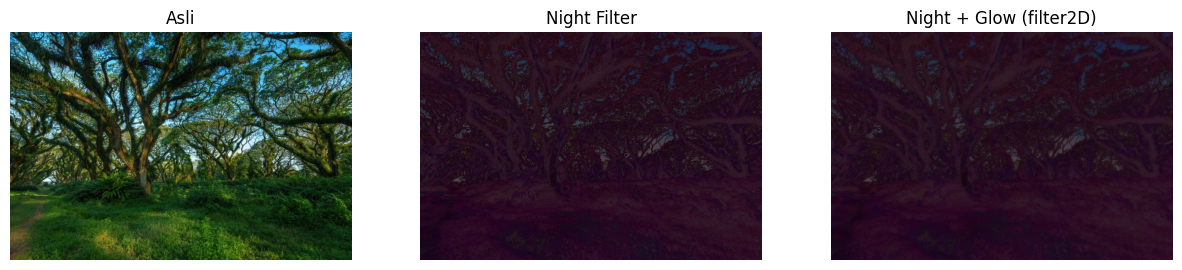

In [27]:
#Night Filter
img = cv.imread("/content/drive/MyDrive//PCVK/Images/djawatan.jpg")
img_gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)

# Step 1: Gelapkan (contrast turun, brightness negatif)
night = cv.convertScaleAbs(img, alpha=0.5, beta=-40)

# Step 2: Tambah bias biru
blue_tint = np.full_like(night, (50, 0, 100)) # BGR
night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)

# Step 3: Efek glow di area terang dengan filter2D (blur kernel)
kernel = np.ones((15, 15), np.float32) / 225
glow = cv.filter2D(night, -1, kernel)

# Kombinasikan asli + glow
night_glow = cv.addWeighted(night, 0.7, glow, 0.3, 0)

show_side_by_side([img, night, night_glow],
                  ["Asli", "Night Filter", "Night + Glow (filter2D)"])

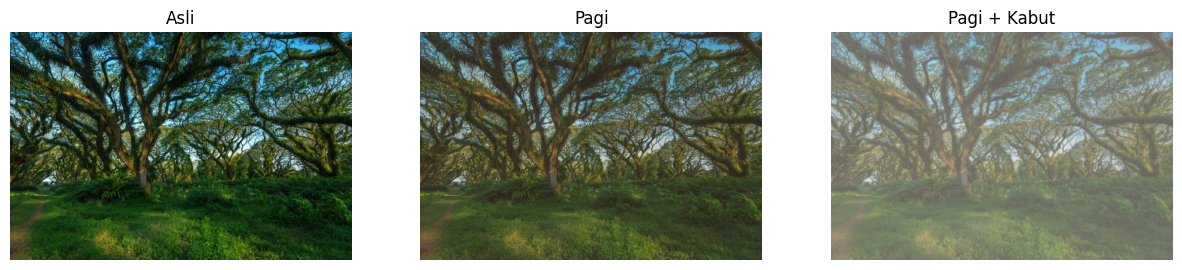

In [28]:
#Filter Suasana pagi dan Kabut
# =========================
# Step 1: Kurangi kontras & cerahkan
# =========================
alpha = 0.9  # contrast
beta = 20    # brightness
soft = cv.convertScaleAbs(img, alpha=alpha, beta=beta)

# =========================
# Step 2: Tambahkan warm tone (kemerahan / oranye)
# =========================
warm_tint = np.full_like(soft, (40, 70, 120)) # BGR
pagi = cv.addWeighted(soft, 0.8, warm_tint, 0.2, 0)

# =========================
# Step 3: Tambahkan haze (kabut tipis) dengan filter2D
# =========================
# Kernel blur Gaussian-like untuk menciptakan efek kabut
kernel = cv.getGaussianKernel(3, 3)
kernel = kernel @ kernel.T # jadikan 2D kernel
kabut = cv.filter2D(pagi, -1, kernel)

# tambah layer putih untuk kabut lebih nyata
white_layer = np.full_like(pagi, 255)
kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)

show_side_by_side([img, pagi, kabut],
                  ["Asli", "Pagi", "Pagi + Kabut"])

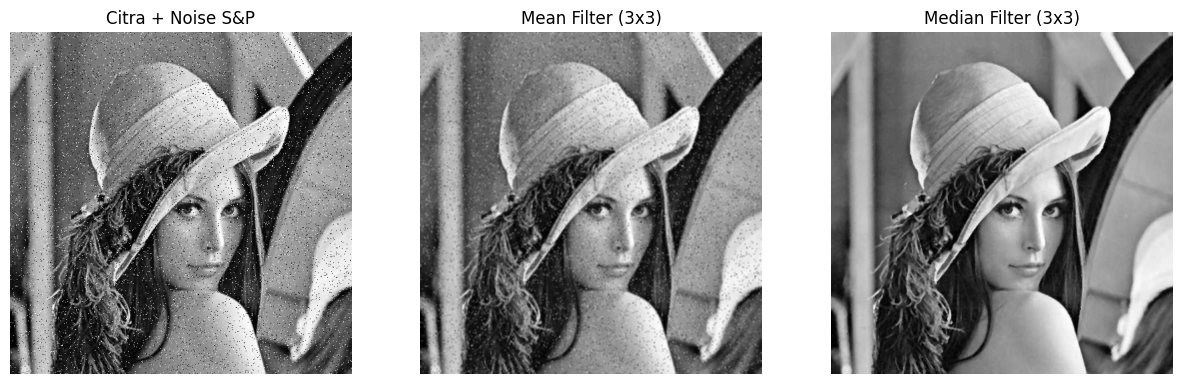

In [30]:
import numpy as np
import cv2 as cv
import random

img = cv.imread("/content/drive/MyDrive/PCVK/Images/lena.jpg")
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# a. Fungsi untuk menambahkan noise Salt and Pepper
def add_salt_pepper_noise(image, amount):
    row, col = image.shape
    out = np.copy(image)

    # Menambahkan Salt (Titik Putih = 255)
    num_salt = np.ceil(amount * image.size * 0.5)
    for _ in range(int(num_salt)):
        y = random.randint(0, row - 1)
        x = random.randint(0, col - 1)
        out[y, x] = 255

    # Menambahkan Pepper (Titik Hitam = 0)
    num_pepper = np.ceil(amount * image.size * 0.5)
    for _ in range(int(num_pepper)):
        y = random.randint(0, row - 1)
        x = random.randint(0, col - 1)
        out[y, x] = 0

    return out

# Menambahkan noise ke citra grayscale dengan intensitas 5% (0.05)
noisy_img = add_salt_pepper_noise(img_gray, 0.05)

# b. Menerapkan Mean Filter (3x3) dan Median Filter (3x3)
mean_filtered = cv.blur(noisy_img, (3, 3))
median_filtered = cv.medianBlur(noisy_img, 3)

# Menampilkan hasil perbandingan
show_side_by_side(
    [noisy_img, mean_filtered, median_filtered],
    ["Citra + Noise S&P", "Mean Filter (3x3)", "Median Filter (3x3)"]
)

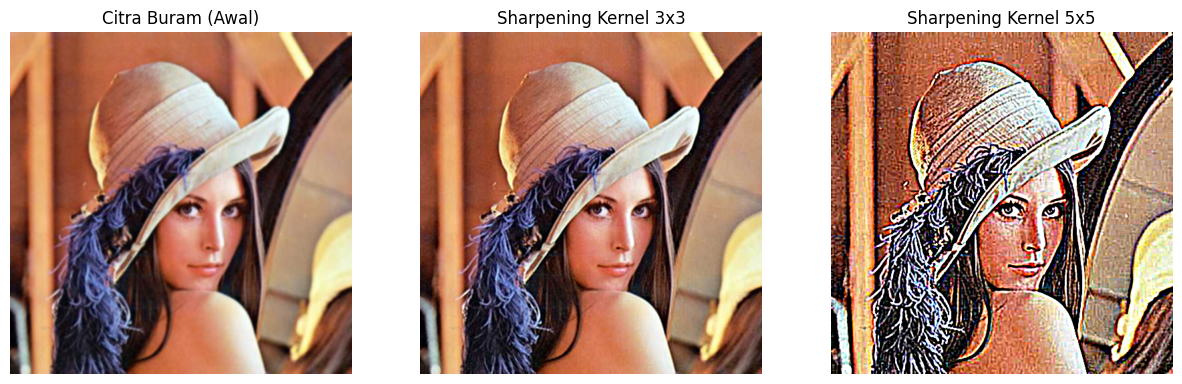

In [31]:
import cv2 as cv
import numpy as np

blurry_img = cv.GaussianBlur(img, (5, 5), 0)

kernel_3x3 = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
])

kernel_5x5 = np.array([
    [-1, -1, -1, -1, -1],
    [-1, -1, -1, -1, -1],
    [-1, -1, 25, -1, -1],
    [-1, -1, -1, -1, -1],
    [-1, -1, -1, -1, -1]
])

sharp_3x3 = cv.filter2D(blurry_img, -1, kernel_3x3)
sharp_5x5 = cv.filter2D(blurry_img, -1, kernel_5x5)

show_side_by_side(
    [blurry_img, sharp_3x3, sharp_5x5],
    ["Citra Buram (Awal)", "Sharpening Kernel 3x3", "Sharpening Kernel 5x5"]
)

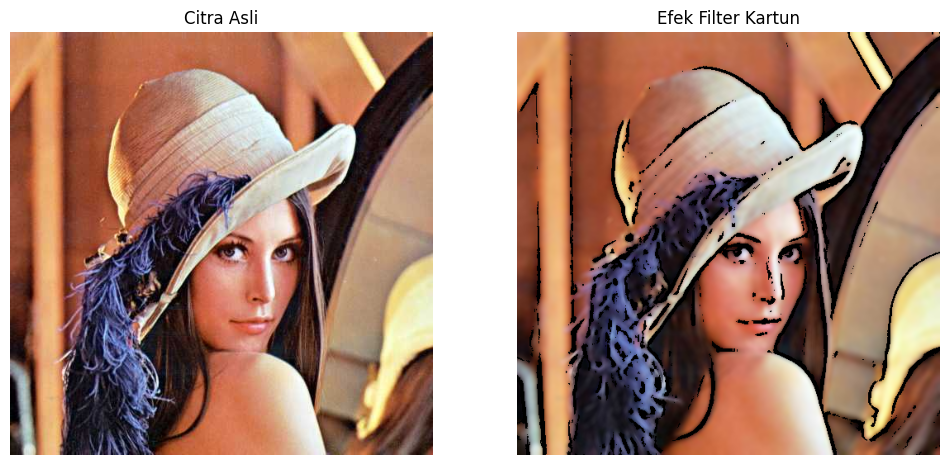

In [32]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def show_side_by_side(images, titles, figsize=(12, 6)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        if len(img.shape) == 2:  # grayscale
            plt.subplot(1, len(images), i + 1)
            plt.imshow(img, cmap="gray")
        else:  # color
            plt.subplot(1, len(images), i + 1)
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()

img_path = "/content/drive/MyDrive/PCVK/Images/lena.jpg"
img = cv.imread(img_path)

if img is None:
    print("Error: Gambar tidak ditemukan. Periksa kembali path Anda!")
else:

    def kartun(image):
        color_smoothed = cv.bilateralFilter(image, d=9, sigmaColor=300, sigmaSpace=300)

        gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)

        gray_blur = cv.medianBlur(gray, 7)

        edges = cv.adaptiveThreshold(
            gray_blur, 255,
            cv.ADAPTIVE_THRESH_MEAN_C,
            cv.THRESH_BINARY, 9, 9
        )

        cartoon_effect = cv.bitwise_and(color_smoothed, color_smoothed, mask=edges)

        return cartoon_effect


    hasil_kartun = kartun(img)

    show_side_by_side(
        [img, hasil_kartun],
        ["Citra Asli", "Efek Filter Kartun"]
    )